# Classificazione con Reti Neurali in PyTorch

In questo notebook impareremo a costruire e addestrare una rete neurale per risolvere un problema di **classificazione**.

Useremo il **dataset Iris**, che contiene misurazioni di 150 fiori di tre specie diverse:
- *Iris setosa*
- *Iris versicolor*
- *Iris virginica*

Per ogni fiore abbiamo 4 caratteristiche (feature):
1. Lunghezza del sepalo (cm)
2. Larghezza del sepalo (cm)
3. Lunghezza del petalo (cm)
4. Larghezza del petalo (cm)

**Obiettivo:** dato un insieme di misurazioni, la rete neurale deve predire a quale delle tre specie appartiene il fiore.

---

## Struttura del notebook

1. Importazione delle librerie
2. Caricamento e preparazione dei dati
3. Definizione della rete neurale (`torch.nn`)
4. Definizione dell'ottimizzatore (`torch.optim`)
5. Il ciclo di addestramento
6. Valutazione del modello
7. Visualizzazione dei risultati

## 1. Importazione delle librerie
Installare pacchetto torch: `pip install torch torchvision torchaudio`

Importiamo tutte le librerie necessarie:
- **`torch`**: il framework principale per il deep learning
- **`torch.nn`**: modulo per definire architetture di reti neurali
- **`torch.optim`**: modulo che contiene gli algoritmi di ottimizzazione
- **`sklearn`**: per caricare il dataset e fare il preprocessing
- **`matplotlib`**: per la visualizzazione dei risultati

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

# Impostiamo un seed per la riproducibilità dei risultati
# Questo garantisce che ogni volta che eseguiamo il notebook otteniamo gli stessi risultati
torch.manual_seed(42)
np.random.seed(42)

print("Librerie importate correttamente")
print(f"Versione di PyTorch: {torch.__version__}")

Librerie importate correttamente
Versione di PyTorch: 2.11.0


## Iperparametri

Prima di tutto definiamo gli **iperparametri** del modello.
Gli iperparametri sono parametri che NON vengono appresi durante l'addestramento,
ma devono essere scelti manualmente prima di iniziare.

- **`EPOCHE`**: quante volte il modello vedrà l'intero dataset durante l'addestramento
- **`LEARNING_RATE`**: la velocità di apprendimento (quanto aggiustare i pesi ad ogni passo)
- **`DIMENSIONE_STRATO_NASCOSTO`**: numero di neuroni negli strati nascosti della rete

In [ ]:
# ============================================================
# IPERPARAMETRI
# ============================================================
EPOCHE = 200                        # Numero di epoche di addestramento
LEARNING_RATE = 0.01                # Velocità di apprendimento
DIMENSIONE_STRATO_NASCOSTO = 16     # Neuroni nello strato nascosto

# Caratteristiche del dataset Iris
NUM_FEATURE = 4    # 4 misurazioni per ogni fiore (num feature = dim input layer)
NUM_CLASSI = 3     # 3 specie di iris

# Nomi delle classi (per la visualizzazione)
NOMI_CLASSI = ['Iris setosa', 'Iris versicolor', 'Iris virginica']

## 2. Caricamento e preparazione dei dati

### Caricamento del dataset

Carichiamo il dataset Iris da scikit-learn e lo dividiamo in:
- **Set di addestramento (training set)**: usato per addestrare il modello (80%)
- **Set di test**: usato per valutare le prestazioni finali (20%)

### Normalizzazione

Applichiamo la **standardizzazione** alle feature:
$$x_{\text{norm}} = \frac{x - \mu}{\sigma}$$

Questo è importante perché:
1. Le reti neurali convergono più velocemente con dati normalizzati
2. Evita che feature con valori grandi dominino quelle con valori piccoli

In [4]:
# ============================================================
# CARICAMENTO DEL DATASET
# ============================================================

# Carichiamo il dataset Iris
iris = load_iris()
X = iris.data    # Feature: (150, 4) - 150 campioni, 4 feature ciascuno
y = iris.target  # Etichette: (150,) - valori 0, 1, 2 per le tre specie

print("=== Informazioni sul Dataset ===")
print(f"Forma del dataset X: {X.shape}")
print(f"Forma delle etichette y: {y.shape}")
print(f"Classi presenti: {np.unique(y)} -> {NOMI_CLASSI}")
print(f"Campioni per classe: {[(y == i).sum() for i in range(3)]}")

# Divisione in training set e test set
# test_size=0.2 significa 20% per il test, 80% per il training
# stratify=y garantisce che la proporzione delle classi sia mantenuta in entrambi i set
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% per il test
    random_state=42,    # seed per riproducibilità
    stratify=y          # mantieni le proporzioni delle classi
)

print(f"\nDimensione training set: {X_train.shape[0]} campioni")
print(f"Dimensione test set: {X_test.shape[0]} campioni")

=== Informazioni sul Dataset ===
Forma del dataset X: (150, 4)
Forma delle etichette y: (150,)
Classi presenti: [0 1 2] -> ['Iris setosa', 'Iris versicolor', 'Iris virginica']
Campioni per classe: [np.int64(50), np.int64(50), np.int64(50)]

Dimensione training set: 120 campioni
Dimensione test set: 30 campioni


In [5]:
# ============================================================
# NORMALIZZAZIONE DEI DATI
# ============================================================

# Creiamo uno StandardScaler
# IMPORTANTE: il fit viene fatto SOLO sul training set,
# poi lo stesso scaler viene applicato al test set
# (non vogliamo che il test set influenzi la normalizzazione!)
scaler = StandardScaler()

# fit_transform: calcola media e deviazione standard del training set, poi trasforma
X_train_scaled = scaler.fit_transform(X_train)

# transform: usa i parametri già calcolati sul training set
X_test_scaled = scaler.transform(X_test)

# ============================================================
# CONVERSIONE IN TENSORI PYTORCH
# ============================================================

# Convertiamo i numpy array in tensori PyTorch
# Le feature vengono convertite in float32 (tipo di default per i calcoli in PyTorch)
X_train_tensor = torch.FloatTensor(X_train_scaled)
X_test_tensor = torch.FloatTensor(X_test_scaled)

# Le etichette vengono convertite in LongTensor (interi a 64 bit, richiesto da CrossEntropyLoss)
y_train_tensor = torch.LongTensor(y_train)
y_test_tensor = torch.LongTensor(y_test)

print("=== Tensori PyTorch ===")
print(f"X_train: {X_train_tensor.shape}, tipo: {X_train_tensor.dtype}")
print(f"y_train: {y_train_tensor.shape}, tipo: {y_train_tensor.dtype}")
print(f"X_test: {X_test_tensor.shape}, tipo: {X_test_tensor.dtype}")
print(f"y_test: {y_test_tensor.shape}, tipo: {y_test_tensor.dtype}")

=== Tensori PyTorch ===
X_train: torch.Size([120, 4]), tipo: torch.float32
y_train: torch.Size([120]), tipo: torch.int64
X_test: torch.Size([30, 4]), tipo: torch.float32
y_test: torch.Size([30]), tipo: torch.int64


### Visualizzazione del dataset

Prima di addestrare il modello, è sempre utile **esplorare visivamente** i dati.
Visualizziamo le distribuzioni delle feature per le tre classi.

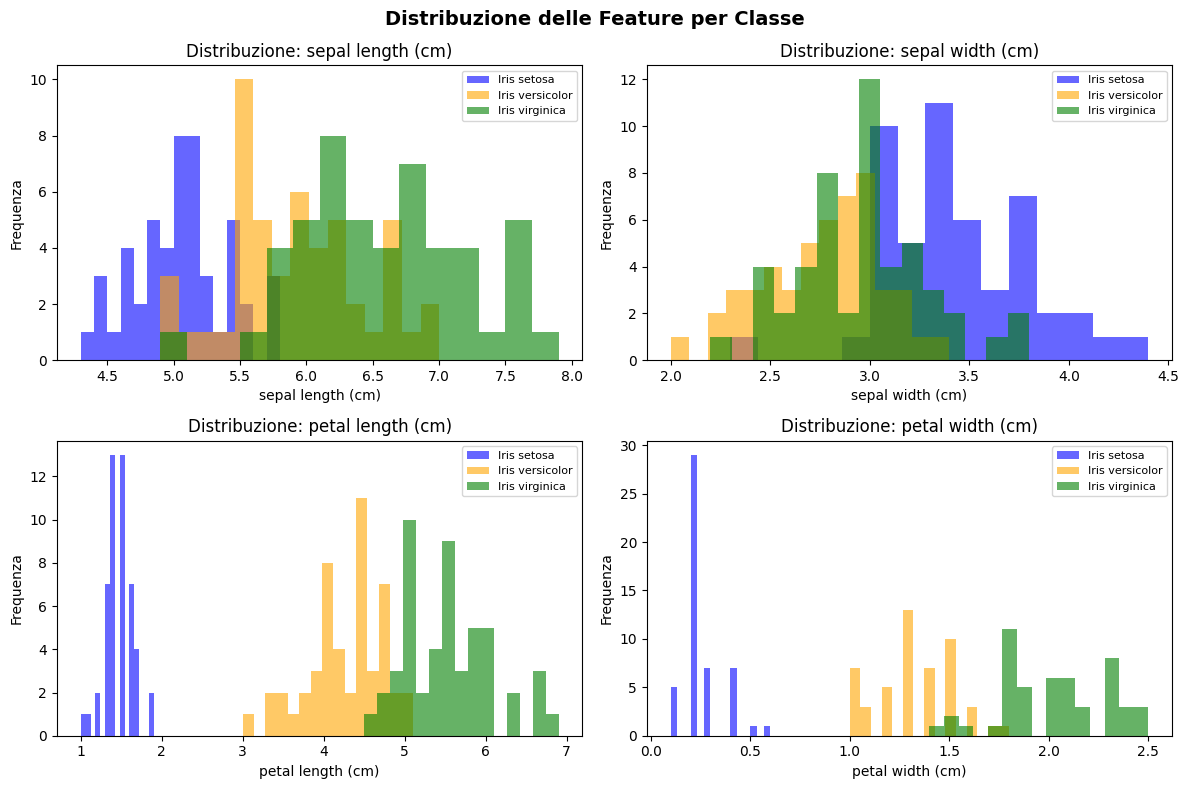

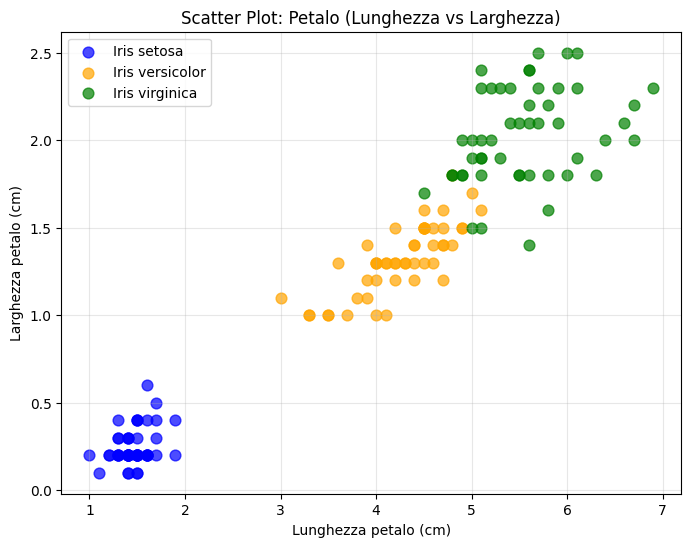

In [6]:
# Visualizzazione della distribuzione delle feature
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
colori = ['blue', 'orange', 'green']
nomi_feature = iris.feature_names

for idx, ax in enumerate(axes.flat):
    for classe in range(3):
        # Prendiamo i valori della feature 'idx' per la classe 'classe'
        valori = X[y == classe, idx]
        ax.hist(valori, bins=15, alpha=0.6, color=colori[classe],
                label=NOMI_CLASSI[classe])
    ax.set_xlabel(nomi_feature[idx])
    ax.set_ylabel('Frequenza')
    ax.set_title(f'Distribuzione: {nomi_feature[idx]}')
    ax.legend(fontsize=8)

plt.suptitle('Distribuzione delle Feature per Classe', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Scatter plot: lunghezza petalo vs larghezza petalo
plt.figure(figsize=(8, 6))
for classe in range(3):
    mask = y == classe
    plt.scatter(X[mask, 2], X[mask, 3],
                c=colori[classe], label=NOMI_CLASSI[classe],
                alpha=0.7, s=60)
plt.xlabel('Lunghezza petalo (cm)')
plt.ylabel('Larghezza petalo (cm)')
plt.title('Scatter Plot: Petalo (Lunghezza vs Larghezza)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. Definizione della Rete Neurale con `torch.nn`

### Il modulo `torch.nn`

Il modulo `torch.nn` fornisce i mattoni fondamentali per costruire reti neurali.
La classe base è `nn.Module`, da cui ereditano tutti i componenti.

Per definire la nostra rete neurale, dobbiamo:
1. **Creare una classe** che eredita da `nn.Module`
2. **Implementare `__init__`**: definisce gli strati della rete
3. **Implementare `forward`**: definisce come i dati fluiscono attraverso la rete

### Architettura della rete

Costruiamo una rete **feedforward** (a propagazione in avanti) con:
- **Strato di input**: 4 neuroni (uno per feature)
- **Primo strato nascosto**: 16 neuroni con attivazione ReLU
- **Secondo strato nascosto**: 8 neuroni con attivazione ReLU
- **Strato di output**: 3 neuroni (uno per classe)

```
Input (4) → Nascosto1 (16) → ReLU → Nascosto2 (8) → ReLU → Output (3)
```

### Funzione di attivazione ReLU

La **ReLU** (Rectified Linear Unit) è definita come:
$$\text{ReLU}(x) = \max(0, x)$$

Introduce **non-linearità** nella rete, permettendole di imparare relazioni complesse.

In [7]:
# ============================================================
# DEFINIZIONE DELLA RETE NEURALE
# ============================================================

class ReteNeurale(nn.Module):
    """
    Rete neurale feedforward per la classificazione del dataset Iris.
    
    Architettura:
        Input (4) -> FC1 (16) -> ReLU -> FC2 (8) -> ReLU -> Output (3)
    """
    
    def __init__(self, num_feature, dim_nascosto, num_classi):
        """
        Nel metodo __init__ definiamo gli strati della rete.
        Ogni strato viene memorizzato come attributo della classe.
        
        nn.Linear(in, out) crea uno strato completamente connesso che calcola:
            y = x * W^T + b
        dove W è la matrice dei pesi e b il vettore dei bias.
        """
        # IMPORTANTE: chiamare sempre super().__init__() per inizializzare
        # correttamente la classe padre nn.Module
        super(ReteNeurale, self).__init__()
        
        # Primo strato completamente connesso:
        # da 4 feature di input a 'dim_nascosto' neuroni
        self.fc1 = nn.Linear(num_feature, dim_nascosto)
        
        # Secondo strato completamente connesso:
        # da 'dim_nascosto' neuroni a metà (dim_nascosto // 2)
        self.fc2 = nn.Linear(dim_nascosto, dim_nascosto // 2)
        
        # Strato di output:
        # da dim_nascosto // 2 neuroni al numero di classi
        self.uscita = nn.Linear(dim_nascosto // 2, num_classi)
    
    def forward(self, x):
        """
        Il metodo forward definisce come i dati scorrono attraverso la rete.
        Viene chiamato automaticamente quando usiamo il modello come una funzione.
        
        NOTA: non si chiama mai forward() direttamente!
              Si usa invece: output = modello(input)
        """
        # Primo strato + attivazione ReLU
        # L'idioma x = F.relu(self.fc1(x)) è comune in PyTorch:
        # 1. self.fc1(x): applica la trasformazione lineare
        # 2. F.relu(...): applica la funzione di attivazione
        x = F.relu(self.fc1(x))
        
        # Secondo strato + attivazione ReLU
        x = F.relu(self.fc2(x))
        
        # Strato di output (SENZA attivazione softmax!)
        # Nota: NON applichiamo softmax qui perché la funzione di perdita
        # nn.CrossEntropyLoss() la applica internamente per efficienza numerica
        x = self.uscita(x)
        
        return x


# Creiamo un'istanza del modello
modello = ReteNeurale(
    num_feature=NUM_FEATURE,
    dim_nascosto=DIMENSIONE_STRATO_NASCOSTO,
    num_classi=NUM_CLASSI
)

# Stampiamo l'architettura del modello
print("=== Architettura della Rete Neurale ===")
print(modello)

# Contiamo il numero totale di parametri apprendibili
totale_parametri = sum(p.numel() for p in modello.parameters() if p.requires_grad)
print(f"\nNumero totale di parametri: {totale_parametri}")

=== Architettura della Rete Neurale ===
ReteNeurale(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (uscita): Linear(in_features=8, out_features=3, bias=True)
)

Numero totale di parametri: 243


## 4. Funzione di perdita e Ottimizzatore

### Funzione di perdita: `nn.CrossEntropyLoss`

Per la classificazione multi-classe, usiamo la **Cross-Entropy Loss**:
$$\mathcal{L} = -\sum_{c=1}^{C} y_c \log(\hat{p}_c)$$

In PyTorch, `nn.CrossEntropyLoss` combina:
- `nn.LogSoftmax()`: converte i logit in probabilità log
- `nn.NLLLoss()`: negative log-likelihood loss

### Ottimizzatore: Adam

Il modulo `torch.optim` fornisce gli algoritmi di ottimizzazione.
Usiamo **Adam** (Adaptive Moment Estimation), uno degli ottimizzatori più usati perché:
- Adatta il learning rate per ogni parametro
- Converge velocemente
- Funziona bene con le impostazioni di default

In [8]:
# ============================================================
# FUNZIONE DI PERDITA E OTTIMIZZATORE
# ============================================================

# Funzione di perdita per classificazione multi-classe
# CrossEntropyLoss si aspetta:
#   - input: tensore di forma (N, C) con i logit grezzi (NON probabilità)
#   - target: tensore di forma (N,) con gli indici delle classi corrette
criterio = nn.CrossEntropyLoss()

# Ottimizzatore Adam
# modello.parameters() restituisce tutti i parametri apprendibili della rete
# lr=LEARNING_RATE è la velocità di apprendimento
ottimizzatore = optim.Adam(modello.parameters(), lr=LEARNING_RATE)

print(f"Funzione di perdita: {criterio}")
print(f"Ottimizzatore: Adam con lr={LEARNING_RATE}")

Funzione di perdita: CrossEntropyLoss()
Ottimizzatore: Adam con lr=0.01


## 5. Il ciclo di addestramento

### La funzione `passo_addestramento`

Definiamo una funzione che esegue un singolo **passo di addestramento** (forward + backward pass).

Il ciclo di addestramento segue sempre questo schema:
1. `ottimizzatore.zero_grad()` — azzera i gradienti precedenti
2. `output = modello(input)` — **forward pass**: calcola le predizioni
3. `perdita = criterio(output, target)` — calcola l'errore
4. `perdita.backward()` — **backward pass**: calcola i gradienti
5. `ottimizzatore.step()` — aggiorna i pesi

### Perché azzerare i gradienti?

In PyTorch, i gradienti si **accumulano** per default. Bisogna azzerarli ad ogni passo,
altrimenti i gradienti di iterazioni diverse si sommerebbero erroneamente.

In [9]:
# ============================================================
# FUNZIONE PER UN SINGOLO PASSO DI ADDESTRAMENTO
# ============================================================

def passo_addestramento(modello, ottimizzatore, criterio, X_batch, y_batch):
    """
    Esegue un singolo passo di addestramento.
    
    Args:
        modello: la rete neurale
        ottimizzatore: l'algoritmo di ottimizzazione
        criterio: la funzione di perdita
        X_batch: il batch di feature di input
        y_batch: le etichette corrette per il batch
    
    Returns:
        Il valore della perdita per questo batch
    """
    # Mettiamo il modello in modalità 'training'
    # Questo è importante per strati come Dropout e BatchNorm
    # che si comportano diversamente durante training e inferenza
    modello.train()
    
    # PASSO 1: Azzeriamo i gradienti accumulati dal passo precedente
    ottimizzatore.zero_grad()
    
    # PASSO 2: Forward pass - calcoliamo le predizioni
    # PyTorch traccia automaticamente tutte le operazioni per il calcolo dei gradienti
    output = modello(X_batch)
    
    # PASSO 3: Calcoliamo la perdita
    perdita = criterio(output, y_batch)
    
    # PASSO 4: Backward pass - calcoliamo i gradienti rispetto a tutti i parametri
    # Questo usa la regola della catena (chain rule) per propagare i gradienti
    perdita.backward()
    
    # PASSO 5: Aggiorniamo i pesi usando i gradienti appena calcolati
    ottimizzatore.step()
    
    return perdita.item()  # .item() converte il tensore in un numero Python


def calcola_accuratezza(modello, X, y):
    """
    Calcola l'accuratezza del modello su un dato set.
    
    Args:
        modello: la rete neurale
        X: feature di input
        y: etichette corrette
    
    Returns:
        Accuratezza come valore tra 0 e 1
    """
    # Mettiamo il modello in modalità 'valutazione'
    modello.eval()
    
    # torch.no_grad() disabilita il calcolo dei gradienti
    # Risparmia memoria e velocizza il calcolo durante la valutazione
    with torch.no_grad():
        output = modello(X)
        
        # torch.max restituisce (valori, indici)
        # Prendiamo l'indice della classe con il logit più alto
        _, predizioni = torch.max(output, dim=1)
        
        # Contiamo quante predizioni sono corrette
        corretti = (predizioni == y).sum().item()
        totale = y.size(0)
        
    return corretti / totale

print("Funzioni definite con successo!")

Funzioni definite con successo!


## Il ciclo principale di addestramento

Ora addestriamo la rete per `EPOCHE` iterazioni.
Per ogni epoca:
1. Eseguiamo un passo di addestramento sull'intero training set
2. Calcoliamo l'accuratezza su training e test set
3. Salviamo le metriche per la visualizzazione

> **Nota**: In questo esempio usiamo l'intero training set come un unico batch (batch gradient descent).
> Per dataset più grandi si usano mini-batch con `DataLoader`.

In [10]:
# ============================================================
# CICLO DI ADDESTRAMENTO
# ============================================================

# Liste per salvare le metriche ad ogni epoca
storia_perdita = []
storia_acc_train = []
storia_acc_test = []

print("=== Inizio Addestramento ===")
print(f"{'Epoca':>6} | {'Perdita':>10} | {'Acc. Train':>12} | {'Acc. Test':>10}")
print("-" * 48)

for epoca in range(EPOCHE):
    # Eseguiamo un passo di addestramento sull'intero training set
    perdita = passo_addestramento(
        modello, ottimizzatore, criterio,
        X_train_tensor, y_train_tensor
    )
    
    # Calcoliamo le accuratezze
    acc_train = calcola_accuratezza(modello, X_train_tensor, y_train_tensor)
    acc_test = calcola_accuratezza(modello, X_test_tensor, y_test_tensor)
    
    # Salviamo le metriche
    storia_perdita.append(perdita)
    storia_acc_train.append(acc_train)
    storia_acc_test.append(acc_test)
    
    # Stampiamo le metriche ogni 20 epoche
    if (epoca + 1) % 20 == 0 or epoca == 0:
        print(f"{epoca+1:>6} | {perdita:>10.4f} | {acc_train:>11.1%} | {acc_test:>9.1%}")

print("-" * 48)
print(f"\nAddestramento completato!")
print(f"Accuratezza finale sul test set: {storia_acc_test[-1]:.1%}")

=== Inizio Addestramento ===
 Epoca |    Perdita |   Acc. Train |  Acc. Test
------------------------------------------------
     1 |     1.0960 |       41.7% |     33.3%
    20 |     0.4414 |       87.5% |     80.0%
    40 |     0.1475 |       95.8% |     93.3%
    60 |     0.0577 |       97.5% |     93.3%
    80 |     0.0402 |       98.3% |     96.7%
   100 |     0.0353 |       98.3% |     96.7%
   120 |     0.0332 |       98.3% |     96.7%
   140 |     0.0319 |       98.3% |     96.7%
   160 |     0.0308 |       98.3% |     96.7%
   180 |     0.0299 |       98.3% |     96.7%
   200 |     0.0292 |       98.3% |     96.7%
------------------------------------------------

Addestramento completato!
Accuratezza finale sul test set: 96.7%


## 6. Visualizzazione dell'andamento dell'addestramento

Visualizziamo come sono cambiate la **perdita** e l'**accuratezza** durante l'addestramento.

- Il grafico della **perdita** dovrebbe diminuire nel tempo (il modello sta imparando)
- Il grafico dell'**accuratezza** dovrebbe aumentare nel tempo

Se la curva del test set è molto peggiore di quella del training set, potrebbe esserci **overfitting**.

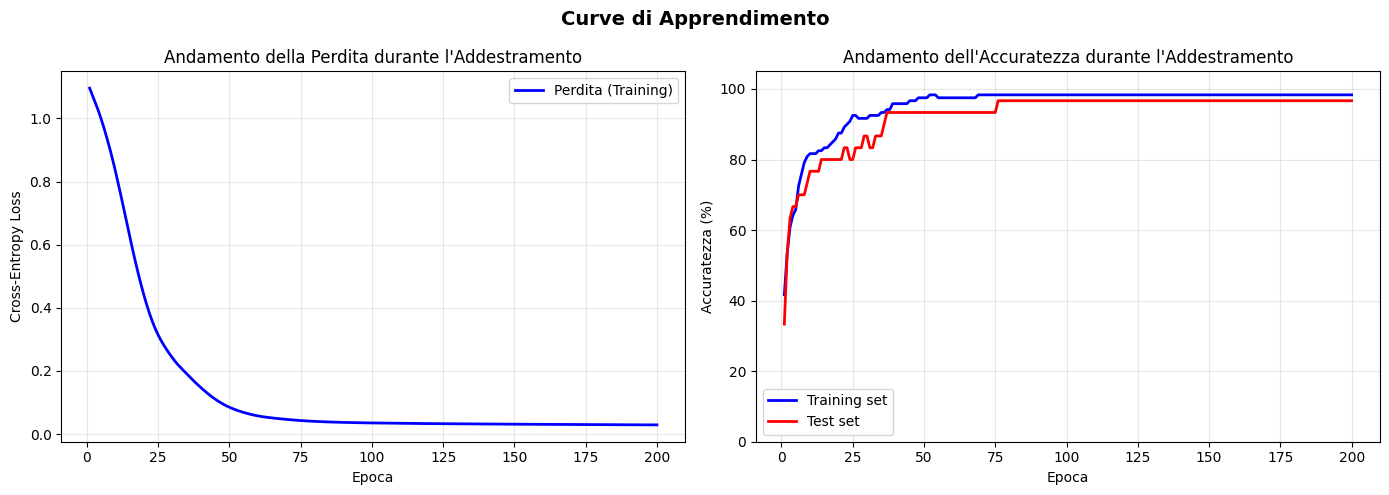

In [11]:
# Visualizzazione dell'andamento dell'addestramento
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epoche = range(1, EPOCHE + 1)

# Grafico della perdita
ax1.plot(epoche, storia_perdita, 'b-', linewidth=2, label='Perdita (Training)')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Andamento della Perdita durante l\'Addestramento')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Grafico dell'accuratezza
ax2.plot(epoche, [a * 100 for a in storia_acc_train], 'b-',
         linewidth=2, label='Training set')
ax2.plot(epoche, [a * 100 for a in storia_acc_test], 'r-',
         linewidth=2, label='Test set')
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Accuratezza (%)')
ax2.set_title('Andamento dell\'Accuratezza durante l\'Addestramento')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 105])

plt.suptitle('Curve di Apprendimento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Valutazione dettagliata del modello

Valutiamo il modello sul test set con metriche più dettagliate:

- **Matrice di confusione**: mostra quante volte ogni classe viene classificata come ogni altra
- **Precision**: per ogni classe, quante predizioni positive erano corrette?
- **Recall**: per ogni classe, quanti campioni positivi sono stati trovati?
- **F1-score**: media armonica di precision e recall

In [12]:
# ============================================================
# VALUTAZIONE FINALE
# ============================================================

# Mettiamo il modello in modalità valutazione
modello.eval()

with torch.no_grad():
    # Otteniamo le predizioni sul test set
    output_test = modello(X_test_tensor)
    
    # Convertiamo i logit in probabilità usando softmax
    probabilita = F.softmax(output_test, dim=1)
    
    # Otteniamo l'indice della classe con probabilità massima
    _, predizioni = torch.max(output_test, dim=1)

# Convertiamo i tensori in numpy per sklearn
y_pred = predizioni.numpy()
y_true = y_test_tensor.numpy()
prob_np = probabilita.numpy()

# Accuratezza finale
acc_finale = (y_pred == y_true).mean()
print(f"Accuratezza finale sul test set: {acc_finale:.1%}")
print(f"Campioni corretti: {(y_pred == y_true).sum()} / {len(y_true)}")
print()

# Report dettagliato di classificazione
print("=== Report di Classificazione ===")
print(classification_report(y_true, y_pred, target_names=NOMI_CLASSI))

Accuratezza finale sul test set: 96.7%
Campioni corretti: 29 / 30

=== Report di Classificazione ===
                 precision    recall  f1-score   support

    Iris setosa       1.00      1.00      1.00        10
Iris versicolor       1.00      0.90      0.95        10
 Iris virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



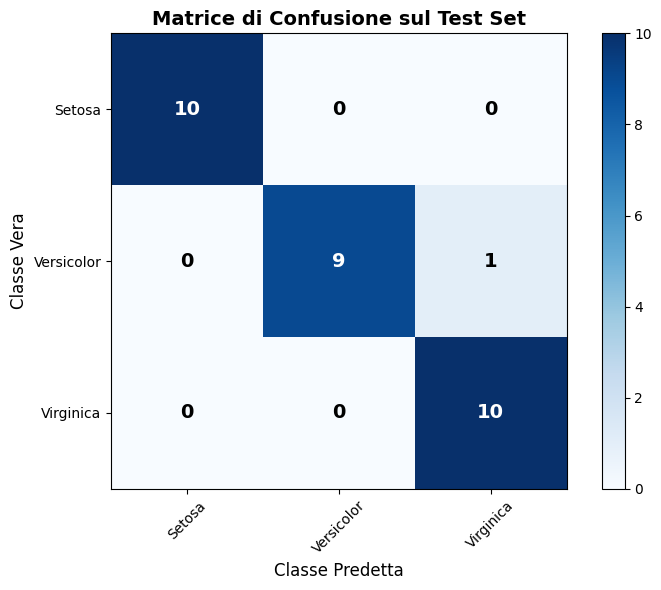


=== Come leggere la matrice di confusione ===
- Ogni riga rappresenta la classe vera
- Ogni colonna rappresenta la classe predetta
- La diagonale principale mostra le predizioni CORRETTE
- Gli elementi fuori diagonale sono gli ERRORI di classificazione


In [13]:
# Visualizzazione della Matrice di Confusione
conf_matrix = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))

# Visualizziamo la matrice come un'immagine colorata
im = ax.imshow(conf_matrix, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

# Aggiungiamo etichette sugli assi
tick_marks = np.arange(NUM_CLASSI)
ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
nomi_brevi = ['Setosa', 'Versicolor', 'Virginica']
ax.set_xticklabels(nomi_brevi, rotation=45)
ax.set_yticklabels(nomi_brevi)

# Aggiungiamo i valori numerici in ogni cella
soglia = conf_matrix.max() / 2.0
for i in range(NUM_CLASSI):
    for j in range(NUM_CLASSI):
        colore_testo = "white" if conf_matrix[i, j] > soglia else "black"
        ax.text(j, i, str(conf_matrix[i, j]),
                ha='center', va='center',
                color=colore_testo, fontsize=14, fontweight='bold')

ax.set_ylabel('Classe Vera', fontsize=12)
ax.set_xlabel('Classe Predetta', fontsize=12)
ax.set_title('Matrice di Confusione sul Test Set', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Spiegazione della matrice di confusione
print("\n=== Come leggere la matrice di confusione ===")
print("- Ogni riga rappresenta la classe vera")
print("- Ogni colonna rappresenta la classe predetta")
print("- La diagonale principale mostra le predizioni CORRETTE")
print("- Gli elementi fuori diagonale sono gli ERRORI di classificazione")

## Riepilogo

In questo notebook abbiamo visto come:

### 1. Preparare i dati
- Dividere il dataset in training e test set
- Normalizzare le feature (StandardScaler)
- Convertire i dati in tensori PyTorch

### 2. Definire una rete neurale (`torch.nn`)
- Creare una classe che eredita da `nn.Module`
- Definire gli strati in `__init__`
- Definire il flusso dei dati in `forward`
- Usare strati `nn.Linear` e attivazioni `F.relu`

### 3. Addestrare il modello
- Definire la funzione di perdita (`nn.CrossEntropyLoss`)
- Definire l'ottimizzatore (`optim.Adam`)
- Eseguire il ciclo: `zero_grad → forward → loss → backward → step`

### 4. Valutare il modello
- Usare `model.eval()` e `torch.no_grad()` per la valutazione
- Calcolare accuratezza, precision, recall e F1-score
- Visualizzare la matrice di confusione

---

### Concetti chiave da ricordare

| Concetto | Descrizione |
|----------|-------------|
| `nn.Module` | Classe base per tutti i modelli PyTorch |
| `forward()` | Definisce il forward pass (MAI chiamare direttamente) |
| `zero_grad()` | Azzera i gradienti prima di ogni passo |
| `backward()` | Calcola i gradienti (backpropagation) |
| `step()` | Aggiorna i parametri usando i gradienti |
| `model.train()` | Modalità addestramento (attiva Dropout, BatchNorm, ...) |
| `model.eval()` | Modalità valutazione |
| `torch.no_grad()` | Disabilita il calcolo dei gradienti (più veloce) |